In [ ]:
## Test code for Julia

using LinearAlgebra

A = [1 2 3 4; 2 3 4 5; 3 4 5 6; 4 5 6 7]
println("Eigenvalues: ", eigvals(A))

Eigenvalues: [-1.1651513899116792, 1.469681086551678e-17, 2.3333190633977975e-15, 17.16515138991168]


In [ ]:
using LinearAlgebra
using Statistics

# 4x4 Hermitian matrix
A = [4.0 3.0 2.0 1.0;
     3.0 4.0 3.0 2.0;
     2.0 3.0 4.0 3.0;
     1.0 2.0 3.0 4.0]

# Warmup
eigvals(Hermitian(A))

# Benchmark
times = Float64[]
for _ in 1:10000
    t0 = time_ns()
    eigvals(Hermitian(A))
    push!(times, (time_ns() - t0) / 1e6)
end

t_julia = mean(times)
println("Julia mean time: $(round(t_julia*1000, digits=3)) µs")
println("Eigenvalues: ", eigvals(Hermitian(A)))

Julia mean time: 1.853 µs
Eigenvalues: [0.5857864376269043, 0.9009804864072157, 3.414213562373094, 11.099019513592784]


In [ ]:
using DelimitedFiles
writedlm("julia_eigen_time.txt", [t_julia])
writedlm("matrix_A.txt", A)
println("✓ Saved")

✓ Saved


### Numpy + Qutip

In [1]:
import numpy as np
import qutip as qt
import time

A = np.loadtxt("matrix_A.txt")

# NumPy
times_np = []
for _ in range(10000):
    t0 = time.perf_counter()
    np.linalg.eigh(A)
    times_np.append(time.perf_counter() - t0)
t_numpy = np.mean(times_np) * 1e6

# QuTiP
A_qt = qt.Qobj(A)
times_qt = []
for _ in range(10000):
    t0 = time.perf_counter()
    A_qt.eigenenergies()
    times_qt.append(time.perf_counter() - t0)
t_qutip = np.mean(times_qt) * 1e6

# Julia result
t_julia = np.loadtxt("julia_eigen_time.txt") * 1000

print(f"NumPy : {t_numpy:.3f} µs")
print(f"QuTiP : {t_qutip:.3f} µs")
print(f"Julia : {t_julia:.3f} µs")

NumPy : 4.847 µs
QuTiP : 17.540 µs
Julia : 1.853 µs


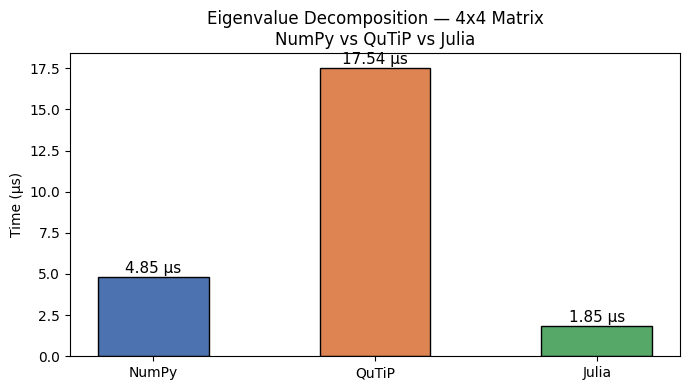

In [2]:
import matplotlib.pyplot as plt

labels  = ['NumPy', 'QuTiP', 'Julia']
timings = [t_numpy, t_qutip, t_julia]
colors  = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, timings, color=colors, edgecolor='black', width=0.5)
plt.ylabel('Time (µs)')
plt.title('Eigenvalue Decomposition — 4x4 Matrix\nNumPy vs QuTiP vs Julia')
for bar, val in zip(bars, timings):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.2, f'{val:.2f} µs', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("eigen_benchmark.png", dpi=150)
plt.show()